# Code for figures

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    FunctionTransformer,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    SplineTransformer,
)
from sklearn.feature_extraction import FeatureHasher
from sklearn.compose import make_column_transformer
from sklearn.linear_model import SGDRegressor, SGDClassifier
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

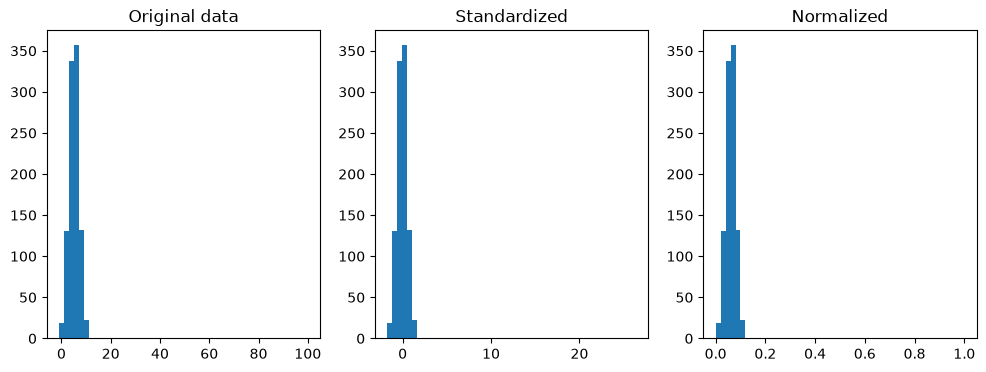

In [2]:
rng = np.random.default_rng(seed=123456)
x = rng.normal(5, 2, 1000)
x[-1] = 100

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(x, bins=50)
axes[0].set_title("Original data")
axes[1].hist((x - x.mean()) / x.std(), bins=50)
axes[1].set_title("Standardized")
axes[2].hist((x - x.min()) / (x.max() - x.min()), bins=50)
axes[2].set_title("Normalized")

# plt.savefig("../../img/05-scaling.png")

## Fake data to demonstrate scaling and nonlinear transforms

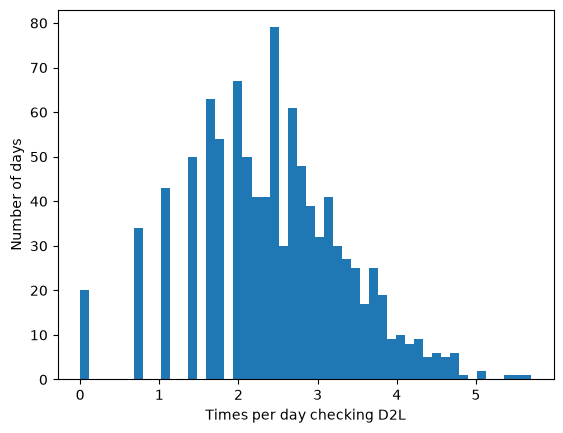

In [3]:
# generate some fake count data
# From Intro to Machine Learning with Python
X_org = rng.normal(size=(1000, 3))
X = rng.poisson(10 * np.exp(X_org))

plt.hist(np.log1p(X[:, 1]), bins=50)

plt.xlabel("Times per day checking D2L")
plt.ylabel("Number of days")

plt.savefig("../../img/05-counts.png")

## Side comment on the central limit theorem

Sums of independent and identically distributed random variables
converge to normal as number of samples increases.

As soon as one of those criteria are missing, you can’t count on it
anymore!

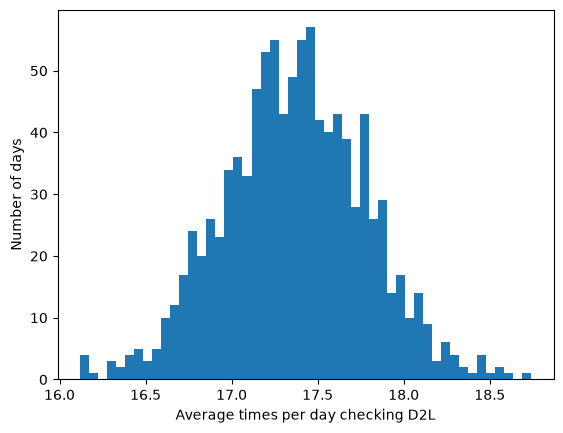

In [4]:
# CLT version
X_c = np.zeros(1000)
for i in range(len(X)):
    X_c[i] = rng.poisson(X[:, 1].mean(), size=100).mean()

plt.hist(X_c, bins=50)

plt.xlabel("Average times per day checking D2L")
plt.ylabel("Number of days")

## Back to the fake data

Create a fake (scalar) output using the “counts” data X (which is
actually a matrix of 3 features) as input.

Note that the data generation doesn’t actually use the count data
directly, but instead is a linearly weighted combination of the normally
distributed random samples that were used as parameters in the poisson
distribution.

In [5]:
# Generate some more fake features and a fake X
# Repeated runs of the same cell results in different values unless we re-seed
rng = np.random.default_rng(seed=42)
w = rng.normal(size=3)
y = X_org.dot(w)

# the usual split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

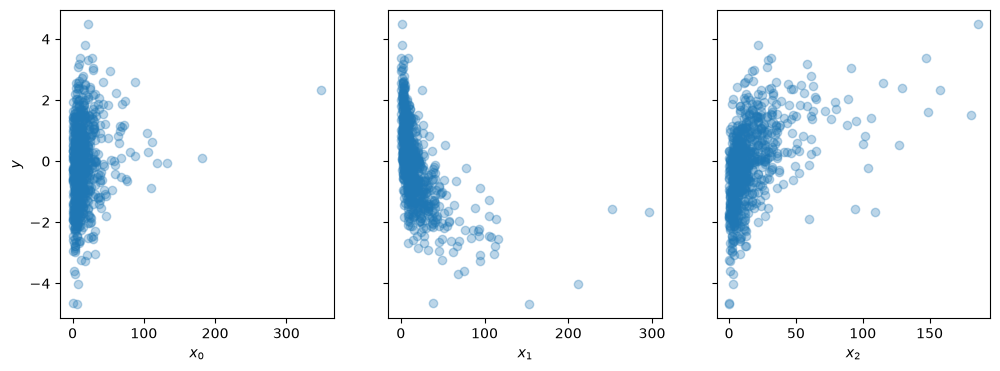

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes[0].set_ylabel("$y$")
for i in range(3):
    axes[i].scatter(X_train[:, i], y_train, alpha=0.3)
    axes[i].set_xlabel(f"$x_{i}$")

(array([633., 217.,  78.,  27.,  17.,   7.,   6.,   9.,   1.,   0.,   2.,
          0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.]),
 array([  0.  ,  14.85,  29.7 ,  44.55,  59.4 ,  74.25,  89.1 , 103.95,
        118.8 , 133.65, 148.5 , 163.35, 178.2 , 193.05, 207.9 , 222.75,
        237.6 , 252.45, 267.3 , 282.15, 297.  ]),
 <BarContainer object of 20 artists>)

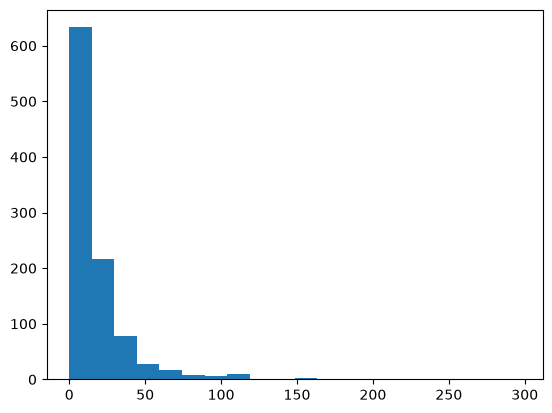

In [12]:
plt.hist(X[:,1], bins=20)

In [7]:
# train a regression model on the raw data using stochastic gradient descent
model = SGDRegressor()
cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error")

array([-6.85645518e+22, -1.87415010e+24, -1.76484861e+24, -3.87067041e+24,
       -6.84274102e+22])

In [27]:
# Add on the preprocessing pipeline
pipeline = make_pipeline(
    FunctionTransformer(np.log1p), # log + 1
    StandardScaler(),
    # PowerTransformer(method="yeo-johnson"), # works, but no better than log + standardize
    model #LinearSVR(max_iter=10000),
)

cross_val_score(pipeline, X_train, y_train, scoring="neg_mean_squared_error").mean()

np.float64(-0.21857656048294222)

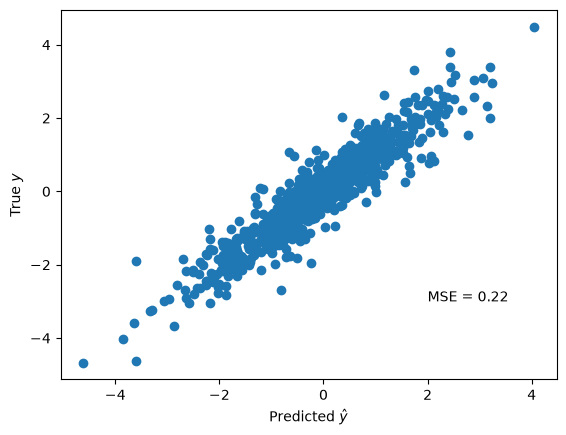

In [26]:
pipeline.fit(X_train, y_train)
y_est = pipeline.predict(X_train)
plt.scatter(y_est, y_train)
plt.xlabel(r"Predicted $\hat{y}$")
plt.ylabel("True $y$")
plt.text(2, -3, f"MSE = {np.mean((y_train - y_est)**2):.2f}")